In [1]:
# ---------------------------------
# Import Libraries
# ---------------------------------

import json
import joblib

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
# ---------------------------------
# Load Trained Model
# ---------------------------------

model = joblib.load(
    "Predictive_Maintenance_Model_20260714_152250.joblib"
)

print(model)

CalibratedClassifierCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                       estimator=RandomForestClassifier(class_weight='balanced',
                                                        max_depth=10,
                                                        min_samples_split=5,
                                                        n_estimators=186,
                                                        random_state=42),
                       method='isotonic')


In [3]:
# ---------------------------------
# Load Dashboard Data
# ---------------------------------

dashboard = pd.read_csv(
    "Dashboard_Data_20260714_152250.csv"
)

dashboard.head()

,Air_temperature_K,Process_temperature_K,Rotational_speed_rpm,Torque_Nm,Tool_wear_min,Power_Index,Wear_Intensity,Thermal_Stress_Index,Failure Probability,Equipment Health Risk Index,Risk Level
0,298.5,309.7,2617,12.1,102,31665.7,1234.2,3747.37,1.000000,100.000000,Critical
1,299.0,310.3,1303,68.6,111,89385.8,7614.6,21286.58,1.000000,100.000000,Critical
2,297.2,308.1,1340,61.3,207,82142.0,12689.1,18886.53,0.985714,98.571429,Critical
3,298.9,309.8,1287,61.9,216,79665.3,13370.4,19176.62,0.970330,97.032967,Critical
4,297.2,307.9,1326,75.4,172,99980.4,12968.8,23215.66,0.969230,96.923045,Critical


In [4]:
# ---------------------------------
# Load Model Configuration
# ---------------------------------

with open(
    "Model_Config_20260714_152250.json",
    "r"
) as f:

    config = json.load(f)

config

{'Model': 'Random Forest',
 'Threshold': 0.4086274509803921,
 'Version': '20260714_152250'}

In [5]:
config.keys()

dict_keys(['Model', 'Threshold', 'Version'])

In [6]:
# ---------------------------------
# Model Information
# ---------------------------------

print("Model")
print(config["Model"])

print()

print("Decision Threshold")
print(config["Threshold"])

print()

print("Model Version")
print(config["Version"])

Model
Random Forest

Decision Threshold
0.4086274509803921

Model Version
20260714_152250


In [7]:
# ---------------------------------
# Dataset Overview
# ---------------------------------

print("Number of Machines :", len(dashboard))

print()

print(dashboard.columns.tolist())

Number of Machines : 2000

['Air_temperature_K', 'Process_temperature_K', 'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min', 'Power_Index', 'Wear_Intensity', 'Thermal_Stress_Index', 'Failure Probability', 'Equipment Health Risk Index', 'Risk Level']


In [8]:
# ---------------------------------
# Highest Risk Machines
# ---------------------------------

dashboard.sort_values(
    by="Equipment Health Risk Index",
    ascending=False
).head(10)

,Air_temperature_K,Process_temperature_K,Rotational_speed_rpm,Torque_Nm,Tool_wear_min,Power_Index,Wear_Intensity,Thermal_Stress_Index,Failure Probability,Equipment Health Risk Index,Risk Level
0,298.5,309.7,2617,12.1,102,31665.7,1234.2,3747.37,1.000000,100.000000,Critical
1,299.0,310.3,1303,68.6,111,89385.8,7614.6,21286.58,1.000000,100.000000,Critical
2,297.2,308.1,1340,61.3,207,82142.0,12689.1,18886.53,0.985714,98.571429,Critical
3,298.9,309.8,1287,61.9,216,79665.3,13370.4,19176.62,0.970330,97.032967,Critical
4,297.2,307.9,1326,75.4,172,99980.4,12968.8,23215.66,0.969230,96.923045,Critical
5,298.6,308.2,1361,68.2,172,92820.2,11730.4,21019.24,0.967224,96.722408,Critical
6,299.6,310.9,1229,65.2,209,80130.8,13626.8,20270.68,0.952938,95.293837,Critical
7,297.4,308.8,1325,62.4,204,82680.0,12729.6,19269.12,0.952938,95.293837,Critical
8,298.6,309.6,1344,59.4,200,79833.6,11880.0,18390.24,0.895596,89.559571,Critical
9,299.1,310.0,1367,56.3,203,76962.1,11428.9,17453.00,0.895596,89.559571,Critical


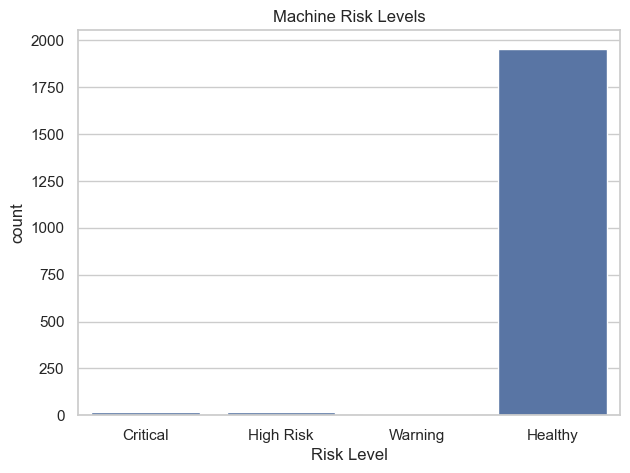

In [9]:
# ---------------------------------
# Risk Level Distribution
# ---------------------------------

plt.figure(figsize=(7,5))

sns.countplot(
    data=dashboard,
    x="Risk Level"
)

plt.title("Machine Risk Levels")

plt.show()

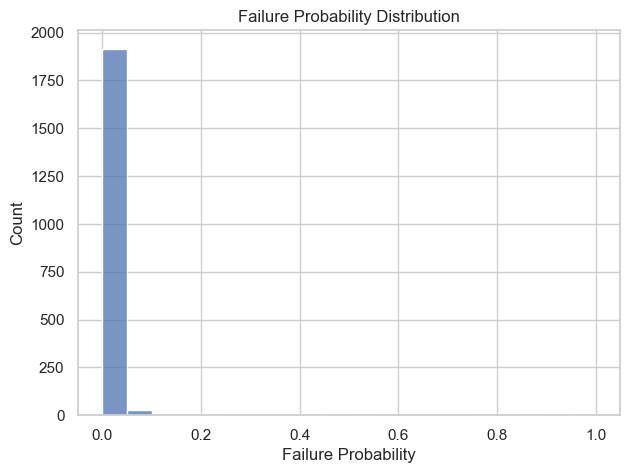

In [10]:
# ---------------------------------
# Failure Probability Distribution
# ---------------------------------

plt.figure(figsize=(7,5))

sns.histplot(
    dashboard["Failure Probability"],
    bins=20
)

plt.title("Failure Probability Distribution")

plt.show()

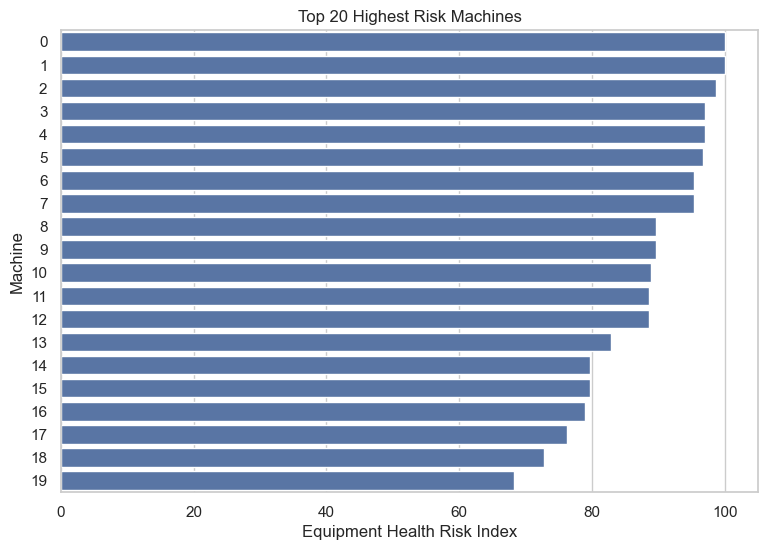

In [11]:
# ---------------------------------
# Top 20 Highest Risk Machines
# ---------------------------------

top20 = dashboard.sort_values(
    by="Equipment Health Risk Index",
    ascending=False
).head(20)

plt.figure(figsize=(9,6))

sns.barplot(
    data=top20,
    x="Equipment Health Risk Index",
    y=top20.index.astype(str)
)

plt.xlabel("Equipment Health Risk Index")

plt.ylabel("Machine")

plt.title("Top 20 Highest Risk Machines")

plt.show()

In [12]:
# ---------------------------------
# Summary Statistics
# ---------------------------------

dashboard.describe()

,Air_temperature_K,Process_temperature_K,Rotational_speed_rpm,Torque_Nm,Tool_wear_min,Power_Index,Wear_Intensity,Thermal_Stress_Index,Failure Probability,Equipment Health Risk Index
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,298.402050,309.395100,1534.493000,40.024800,106.246000,60016.834850,4245.573100,12383.168435,0.017941,1.794136
std,0.901913,1.052492,165.329244,9.655519,63.124265,9913.869967,2800.196775,2986.184423,0.101318,10.131799
min,296.700000,307.400000,1181.000000,12.100000,0.000000,31665.700000,0.000000,3747.370000,0.000000,0.000000
25%,297.500000,308.600000,1425.750000,33.300000,51.000000,53397.900000,1947.600000,10312.177500,0.000000,0.000000
50%,298.400000,309.200000,1504.000000,40.100000,106.000000,59793.300000,3922.400000,12406.335000,0.000587,0.058737
75%,298.900000,310.100000,1609.000000,46.400000,161.000000,66754.150000,6226.400000,14368.717500,0.001986,0.198597
max,301.000000,312.100000,2636.000000,75.400000,246.000000,99980.400000,13626.800000,23215.660000,1.000000,100.000000
